<a href="https://colab.research.google.com/github/Egi341/datascience/blob/main/Pertemuan13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Egi Gunawan
NIM : 240401010166
Kelas : IF401
jurusan : Informatika

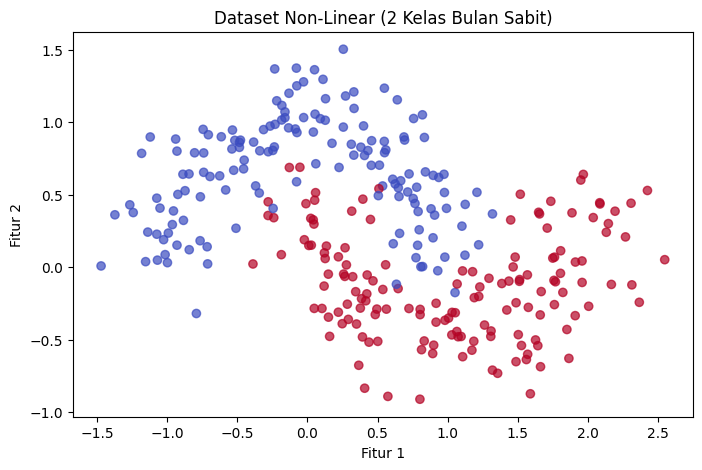

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)


Akurasi pada data uji (Neural Network): 0.850



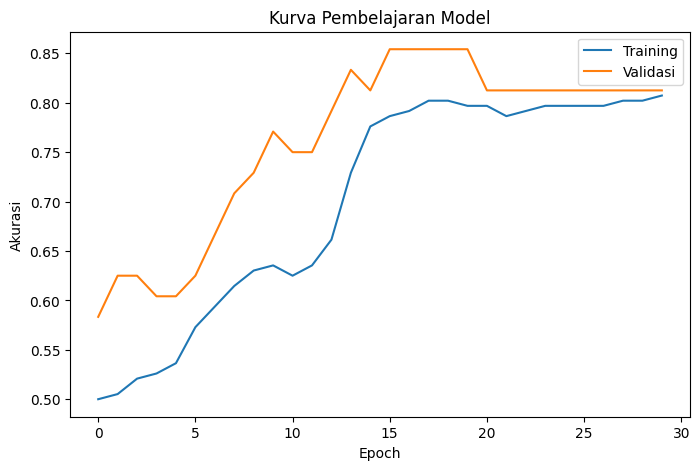

--- Eksplorasi TF-IDF ---
Jumlah kata unik: 149
10 Kata unik pertama: ['ada' 'adminnya' 'akan' 'alias' 'aman' 'amanah' 'aslinya' 'bagus'
 'bahannya' 'baik']
-------------------------

Akurasi model sentimen (Logistic Regression): 0.625
Kalimat Baru: 'Pelayanan sangat memuaskan dan ramah'
Hasil Prediksi Sentimen: Positif


In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset make_moons sebanyak 300 sampel
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualisasi dataset
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split data menjadi training dan testing (80:20)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun arsitektur Sequential Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Kompilasi model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Menampilkan ringkasan arsitektur
model.summary()

# Melatih model
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'\nAkurasi pada data uji (Neural Network): {acc:.3f}\n')

# Plot kurva akurasi
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

ulasan = [
    # 20 Ulasan Positif (Label: 1)
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Kualitas produk sangat baik, respon penjual cepat',
    'Barang original dan berfungsi dengan normal',
    'Packing aman rapi, kurirnya ramah',
    'Produk original, pengemasan sangat cepat dan aman',
    'Sesuai pesanan, bahannya tebal dan nyaman dipakai',
    'Bagus sekali tidak menyesal beli di toko ini',
    'Harga murah tapi kualitas tidak murahan, mantap',
    'Pengiriman kilat baru pesan kemarin sore hari ini sudah sampai',
    'Sangat puas dengan pelayanan toko ini, terima kasih seller',
    'Barang berfungsi dengan baik tanpa ada cacat sedikitpun',
    'Sangat direkomendasikan untuk yang mencari produk berkualitas',
    'Ukuran pas warna sesuai foto produk realpict banget',
    'Pelayanan ramah adminnya komunikatif membantu sekali',
    'Kualitas bintang lima harga kaki lima top banget',
    'Sudah langganan di sini selalu puas dengan produknya',
    'Produk dikirim sesuai dengan estimasi waktu mantap',
    'Bonusnya banyak dan berfungsi dengan sangat baik',

    # 20 Ulasan Negatif (Label: 0)
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pengiriman lambat sekali, kapok belanja di sini',
    'Respon penjual sangat lambat tidak komunikatif',
    'Barang cacat dan pecah saat dibuka dari kemasan',
    'Kecewa berat warna tidak sesuai yang saya pesan',
    'Bahannya tipis dan mudah robek tidak rekomendasi',
    'Ukurannya terlalu kecil tidak muat padahal pesan XL',
    'Barang tidak berfungsi sama sekali alias rusak',
    'Penjual tidak amanah pesan dua yang dikirim cuma satu',
    'Proses pengemasan lama sekali hampir dibatalkan otomatis',
    'Packing kurang aman kardusnya penyok sampai dalam',
    'Kualitas mengecewakan tidak sebanding dengan harganya',
    'Kapok beli di sini pelayanannya buruk sekali',
    'Deskripsi produk menipu tidak sesuai aslinya',
    'Tombolnya macet tidak bisa digunakan dengan baik',
    'Jahitannya tidak rapi banyak benang yang lepas',
    'Pengiriman molor seminggu padahal pakai yang reguler',
    'Komplain tidak direspon penjualnya cuek sekali'
]

# Label: 1 = positif, 0 = negatif (20 positif diikuti 20 negatif)
label = [1]*20 + [0]*20

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('--- Eksplorasi TF-IDF ---')
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 Kata unik pertama:', tfidf.get_feature_names_out()[:10])
print('-------------------------\n')

from sklearn.linear_model import LogisticRegression

# Split data teks (80:20)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

# Menggunakan Logistic Regression untuk klasifikasi sentimen
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# Evaluasi akurasi model sentimen
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen (Logistic Regression): {akurasi:.3f}')

# Uji coba dengan kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print(f"Kalimat Baru: '{kalimat_baru[0]}'")
print('Hasil Prediksi Sentimen:', 'Positif' if pred[0] == 1 else 'Negatif')